<a href="https://colab.research.google.com/github/ps-research/The-Language-of-AI-Liability/blob/main/Regulatory_Specificity_Index.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regulatory Specificity Index
ACL SRW 2026: The Language of AI Liability

Dimensions:
  1. Numeric precision ratio
  2. Definitional density
  3. Temporal precision ratio
  4. Hedge density (inverted for radar: low hedge = high precision)

Produces:
  Figure 5a: Specificity heatmap (all 10 laws x 4 dimensions)
  Figure 5b: Radar chart (selected laws, contrasting profiles)
  Exports: 1200 DPI PDFs + JSON results

In [ ]:
# ── Cell 1: Setup and load ──

import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path
from collections import Counter

BASE_DIR = Path("/content/drive/MyDrive/ACL SRW TEXTS")
OUTPUT_DIR = BASE_DIR / "processed"
FIGURE_DIR = BASE_DIR / "figures"

with open(OUTPUT_DIR / "preprocessed_corpus.json", "r", encoding="utf-8") as f:
    results = json.load(f)

LAW_ORDER = [
    "eu_ai_act", "china_genai", "south_korea",
    "ca_sb1047", "ca_sb53", "ca_sb942", "ca_ab2013",
    "co_sb205", "tx_traiga", "il_hb3773",
]

LAW_LABELS = {
    "eu_ai_act":   "EU AI Act",
    "china_genai":  "China GenAI Measures",
    "south_korea":  "South Korea AI Basic Act",
    "ca_sb1047":    "CA SB 1047 (vetoed)",
    "ca_sb53":      "CA SB 53",
    "ca_sb942":     "CA SB 942",
    "ca_ab2013":    "CA AB 2013",
    "co_sb205":     "CO SB 205",
    "tx_traiga":    "TX TRAIGA",
    "il_hb3773":    "IL HB 3773",
}

print(f"Loaded {len(results)} laws")

Loaded 10 laws


In [ ]:
# ── Cell 2: Dimension 1 — Numeric precision ratio ──

NUMERIC_PATTERNS = re.compile(
    r'\$[\d,]+(?:\.\d+)?'            # dollar amounts
    r'|\d+\s*(?:percent|%)'          # percentages
    r'|\d+\s*(?:days?|hours?|months?|years?|weeks?)\b'  # time periods
    r'|\d{1,3}(?:,\d{3})+\b'        # large numbers with commas
    r'|\b\d+(?:\.\d+)?\s*(?:FLOP|flop|FLOPs|TFLOP)'  # compute thresholds
    r'|\b10\s*\^\s*\d+'              # scientific notation
    r'|\b\d+(?:\.\d+)?\s*(?:million|billion|trillion)\b'  # word numbers
    r'|\b(?:€|EUR)\s*[\d,]+'        # euro amounts
    r'|\b\d+(?:\.\d+)?\s*(?:GB|TB|MB)\b',  # data sizes
    re.IGNORECASE
)

print("Computing numeric precision...")

numeric_results = {}
for law_id in LAW_ORDER:
    sents = results[law_id]["sentences"]
    obligation_sents = [s for s in sents if s["is_obligation"]]
    n_oblig = len(obligation_sents)

    sents_with_numeric = 0
    all_matches = []
    for s in obligation_sents:
        matches = NUMERIC_PATTERNS.findall(s["text"])
        if matches:
            sents_with_numeric += 1
            all_matches.extend(matches)

    ratio = sents_with_numeric / n_oblig if n_oblig > 0 else 0

    numeric_results[law_id] = {
        "sents_with_numeric": sents_with_numeric,
        "n_obligation": n_oblig,
        "ratio": float(ratio),
        "sample_matches": all_matches[:10],
    }

    print(f"  {law_id:<22} {sents_with_numeric:>3}/{n_oblig:<3} "
          f"({ratio:.2%})  samples: {all_matches[:3]}")

Computing numeric precision...
  eu_ai_act               20/710 (2.82%)  samples: ['24 hours', '30 days', '10 years']
  china_genai              0/16  (0.00%)  samples: []
  south_korea              2/102 (1.96%)  samples: ['30 million', '30 million']
  ca_sb1047                4/56  (7.14%)  samples: ['$100', '72 hours', '72 hours']
  ca_sb53                  3/54  (5.56%)  samples: ['30 days', '15 days', '24 hours']
  ca_sb942                 2/13  (15.38%)  samples: ['96 hours', '$5,000']
  ca_ab2013                0/3   (0.00%)  samples: []
  co_sb205                 0/25  (0.00%)  samples: []
  tx_traiga                4/43  (9.30%)  samples: ['18 years', '$10,000', '$12,000']
  il_hb3773                2/16  (12.50%)  samples: ['5 days', '30 days']


In [ ]:
# ── Cell 3: Dimension 2 — Definitional density ──

DEFINITION_MARKERS = re.compile(
    r'["\u201c]([^"\u201d]{2,60})["\u201d]\s+means\b'
    r'|\b(\w[\w\s]{2,40}?)\s+means\b'
    r'|\bas\s+defined\s+in\b'
    r'|\bfor\s+(?:the\s+)?purposes?\s+of\s+this\b'
    r'|\bhas\s+the\s+(?:same\s+)?meaning',
    re.IGNORECASE
)

print("\nComputing definitional density...")

definitional_results = {}
for law_id in LAW_ORDER:
    sents = results[law_id]["sentences"]
    all_sents = sents
    obligation_sents = [s for s in sents if s["is_obligation"]]

    # Count formally defined terms across the entire law
    defined_terms = set()
    for s in all_sents:
        matches = DEFINITION_MARKERS.findall(s["text"])
        for groups in matches:
            term = next((g.strip().lower() for g in groups if g.strip()), None)
            if term and 2 < len(term) < 60:
                defined_terms.add(term)

    # Count unique noun phrases appearing more than once in obligation sentences
    # Use simple regex-based NP extraction (word sequences before deontic modals)
    # to avoid re-running spaCy
    np_counter = Counter()
    NP_PATTERN = re.compile(r'\b(?:the|a|an|each|every|any|all)\s+'
                            r'(?:\w+\s+){0,3}\w+(?:\s+\w+)?', re.IGNORECASE)
    for s in obligation_sents:
        nps = NP_PATTERN.findall(s["text"])
        for np_text in nps:
            np_clean = np_text.strip().lower()
            if len(np_clean) > 3:
                np_counter[np_clean] += 1

    # Filter to NPs appearing more than once
    recurring_nps = {np for np, count in np_counter.items() if count > 1}
    n_recurring = len(recurring_nps)

    density = len(defined_terms) / n_recurring if n_recurring > 0 else 0

    definitional_results[law_id] = {
        "defined_terms": len(defined_terms),
        "recurring_nps": n_recurring,
        "density": float(density),
        "sample_terms": list(defined_terms)[:10],
    }

    print(f"  {law_id:<22} defined={len(defined_terms):>3}  "
          f"recurring_nps={n_recurring:>4}  density={density:.3f}  "
          f"terms: {list(defined_terms)[:3]}")


Computing definitional density...
  eu_ai_act              defined= 13  recurring_nps= 420  density=0.031  terms: ['through electronic communication', 'after all other reasonable', 'the technical']
  china_genai            defined=  1  recurring_nps=   4  density=0.250  terms: ['through programmable interfaces and other']
  south_korea            defined= 10  recurring_nps=  39  density=0.256  terms: ['generative ai', 'core operations and management of', 'ai ethics']
  ca_sb1047              defined= 19  recurring_nps=  38  density=0.500  terms: ['including by', 'advanced persistent threat', 'safety and security protocol']
  ca_sb53                defined= 13  recurring_nps=  32  density=0.406  terms: ['large frontier developer', 'property', 'affiliate']
  ca_sb942               defined=  8  recurring_nps=   8  density=1.000  terms: ['system provenance data', 'latent', 'personal provenance data']
  ca_ab2013              defined=  6  recurring_nps=   2  density=3.000  terms: ['artific

In [ ]:
# ── Cell 4: Dimension 3 — Temporal precision ratio ──

PRECISE_TEMPORAL = re.compile(
    r'\bwithin\s+\d+\s+(?:days?|hours?|months?|years?|weeks?|business\s+days?)\b'
    r'|\bno\s+later\s+than\b'
    r'|\bno\s+earlier\s+than\b'
    r'|\bby\s+(?:January|February|March|April|May|June|July|August|'
    r'September|October|November|December)\s+\d+'
    r'|\bby\s+\d{1,2}/\d{1,2}/\d{2,4}'
    r'|\beffective\s+(?:January|February|March|April|May|June|July|August|'
    r'September|October|November|December)\s+\d+'
    r'|\bannually\b'
    r'|\bevery\s+\d+\s+(?:days?|months?|years?)\b'
    r'|\bbiannually\b'
    r'|\bquarterly\b'
    r'|\bsemiannually\b'
    r'|\bon\s+or\s+before\s+(?:January|February|March|April|May|June|July|August|'
    r'September|October|November|December)\s+\d+'
    r'|\b(?:January|February|March|April|May|June|July|August|'
    r'September|October|November|December)\s+\d+,?\s+\d{4}',
    re.IGNORECASE
)

VAGUE_TEMPORAL = re.compile(
    r'\bpromptly\b'
    r'|\bin\s+a\s+timely\s+manner\b'
    r'|\bas\s+soon\s+as\s+practicable\b'
    r'|\bas\s+soon\s+as\s+possible\b'
    r'|\bperiodically\b'
    r'|\bfrom\s+time\s+to\s+time\b'
    r'|\bwithout\s+(?:undue\s+)?delay\b'
    r'|\bin\s+due\s+(?:course|time)\b'
    r'|\bat\s+regular\s+intervals\b'
    r'|\bregularly\b'
    r'|\bwithout\s+unnecessary\s+delay\b',
    re.IGNORECASE
)

print("\nComputing temporal precision...")

temporal_results = {}
for law_id in LAW_ORDER:
    sents = results[law_id]["sentences"]
    obligation_sents = [s for s in sents if s["is_obligation"]]

    precise_count = 0
    vague_count = 0
    precise_matches = []
    vague_matches = []

    for s in obligation_sents:
        p = PRECISE_TEMPORAL.findall(s["text"])
        v = VAGUE_TEMPORAL.findall(s["text"])
        precise_count += len(p)
        vague_count += len(v)
        precise_matches.extend(p)
        vague_matches.extend(v)

    total_temporal = precise_count + vague_count
    ratio = precise_count / total_temporal if total_temporal > 0 else 0

    temporal_results[law_id] = {
        "precise": precise_count,
        "vague": vague_count,
        "total": total_temporal,
        "ratio": float(ratio),
        "precise_samples": precise_matches[:5],
        "vague_samples": vague_matches[:5],
    }

    print(f"  {law_id:<22} precise={precise_count:>3}  vague={vague_count:>3}  "
          f"ratio={ratio:.2f}  "
          f"p_samples={precise_matches[:2]}  v_samples={vague_matches[:2]}")


Computing temporal precision...
  eu_ai_act              precise= 11  vague= 38  ratio=0.22  p_samples=['within 24 hours', 'no later than']  v_samples=['without undue delay', 'without undue delay']
  china_genai            precise=  1  vague=  3  ratio=0.25  p_samples=['August 15, 2023']  v_samples=['promptly', 'promptly']
  south_korea            precise=  2  vague=  0  ratio=1.00  p_samples=['January 21, 2025', 'January 24, 2026']  v_samples=[]
  ca_sb1047              precise= 18  vague=  2  ratio=0.90  p_samples=['by January 1', 'January 1, 2026']  v_samples=['promptly', 'periodically']
  ca_sb53                precise= 10  vague=  1  ratio=0.91  p_samples=['within 30 days', 'within 15 days']  v_samples=['periodically']
  ca_sb942               precise=  2  vague=  0  ratio=1.00  p_samples=['within 96 hours', 'January 1, 2026']  v_samples=[]
  ca_ab2013              precise=  2  vague=  0  ratio=1.00  p_samples=['On or before January 1', 'January 1, 2022']  v_samples=[]
  co_sb205

In [ ]:
# ── Cell 5: Dimension 4 — Hedge density ──

HEDGE_WORDS = re.compile(
    r'\breasonable\b'
    r'|\breasonably\b'
    r'|\bappropriate\b'
    r'|\bappropriately\b'
    r'|\badequate\b'
    r'|\badequately\b'
    r'|\bsufficient\b'
    r'|\bsufficiently\b'
    r'|\bmaterial\b'
    r'|\bmaterially\b'
    r'|\bsignificant\b'
    r'|\bsignificantly\b'
    r'|\bas\s+applicable\b'
    r'|\bas\s+necessary\b'
    r'|\bas\s+appropriate\b'
    r'|\bto\s+the\s+extent\s+practicable\b'
    r'|\bto\s+the\s+extent\s+possible\b'
    r'|\bwhere\s+appropriate\b'
    r'|\bwhere\s+applicable\b'
    r'|\bwhere\s+necessary\b'
    r'|\bproportionate\b'
    r'|\bsuitable\b'
    r'|\bfeasible\b',
    re.IGNORECASE
)

print("\nComputing hedge density...")

hedge_results = {}
for law_id in LAW_ORDER:
    sents = results[law_id]["sentences"]
    obligation_sents = [s for s in sents if s["is_obligation"]]
    n_oblig = len(obligation_sents)

    total_hedges = 0
    hedge_matches = []
    for s in obligation_sents:
        matches = HEDGE_WORDS.findall(s["text"])
        total_hedges += len(matches)
        hedge_matches.extend(matches)

    density = total_hedges / n_oblig if n_oblig > 0 else 0

    hedge_results[law_id] = {
        "total_hedges": total_hedges,
        "n_obligation": n_oblig,
        "density": float(density),
        "sample_hedges": hedge_matches[:10],
    }

    print(f"  {law_id:<22} hedges={total_hedges:>3}  "
          f"oblig={n_oblig:>3}  density={density:.3f}  "
          f"samples: {hedge_matches[:4]}")


Computing hedge density...
  eu_ai_act              hedges=274  oblig=710  density=0.386  samples: ['proportionate', 'significant', 'materially', 'significant']
  china_genai            hedges=  1  oblig= 16  density=0.062  samples: ['feasible']
  south_korea            hedges= 12  oblig=102  density=0.118  samples: ['significantly', 'reasonably', 'as necessary', 'appropriate']
  ca_sb1047              hedges= 51  oblig= 56  density=0.911  samples: ['materially', 'reasonably', 'materially', 'materially']
  ca_sb53                hedges= 21  oblig= 54  density=0.389  samples: ['material', 'significantly', 'reasonable', 'sufficient']
  ca_sb942               hedges=  8  oblig= 13  density=0.615  samples: ['reasonable', 'appropriate', 'reasonable', 'feasible']
  ca_ab2013              hedges=  0  oblig=  3  density=0.000  samples: []
  co_sb205               hedges= 31  oblig= 25  density=1.240  samples: ['REASONABLE', 'REASONABLY', 'REASONABLE', 'REASONABLY']
  tx_traiga              he

In [ ]:
# ── Cell 6: Compile summary ──

specificity_df = pd.DataFrame({
    "Numeric Precision": {lid: numeric_results[lid]["ratio"] for lid in LAW_ORDER},
    "Definitional Density": {lid: definitional_results[lid]["density"] for lid in LAW_ORDER},
    "Temporal Precision": {lid: temporal_results[lid]["ratio"] for lid in LAW_ORDER},
    "Hedge Density": {lid: hedge_results[lid]["density"] for lid in LAW_ORDER},
}).loc[LAW_ORDER]

print("\n" + "=" * 70)
print("REGULATORY SPECIFICITY INDEX — RAW VALUES")
print("=" * 70)
print(specificity_df.round(3).to_string())

# For radar chart: invert hedge density so all axes point toward "more specific"
# Obligation Precision = 1 - normalized_hedge_density
max_hedge = specificity_df["Hedge Density"].max()
specificity_df["Obligation Precision"] = 1 - (specificity_df["Hedge Density"] / max_hedge) if max_hedge > 0 else 1

# Normalize all dimensions to 0-1 for the radar chart
radar_df = specificity_df[["Numeric Precision", "Definitional Density",
                            "Temporal Precision", "Obligation Precision"]].copy()
for col in radar_df.columns:
    col_max = radar_df[col].max()
    if col_max > 0:
        radar_df[col] = radar_df[col] / col_max

print(f"\nNormalized values for radar chart (0-1 scale, all axes = more specific):")
print(radar_df.round(3).to_string())


REGULATORY SPECIFICITY INDEX — RAW VALUES
             Numeric Precision  Definitional Density  Temporal Precision  Hedge Density
eu_ai_act                0.028                 0.031               0.224          0.386
china_genai              0.000                 0.250               0.250          0.062
south_korea              0.020                 0.256               1.000          0.118
ca_sb1047                0.071                 0.500               0.900          0.911
ca_sb53                  0.056                 0.406               0.909          0.389
ca_sb942                 0.154                 1.000               1.000          0.615
ca_ab2013                0.000                 3.000               1.000          0.000
co_sb205                 0.000                 0.289               0.897          1.240
tx_traiga                0.093                 0.536               1.000          0.326
il_hb3773                0.125                 3.400               0.000     

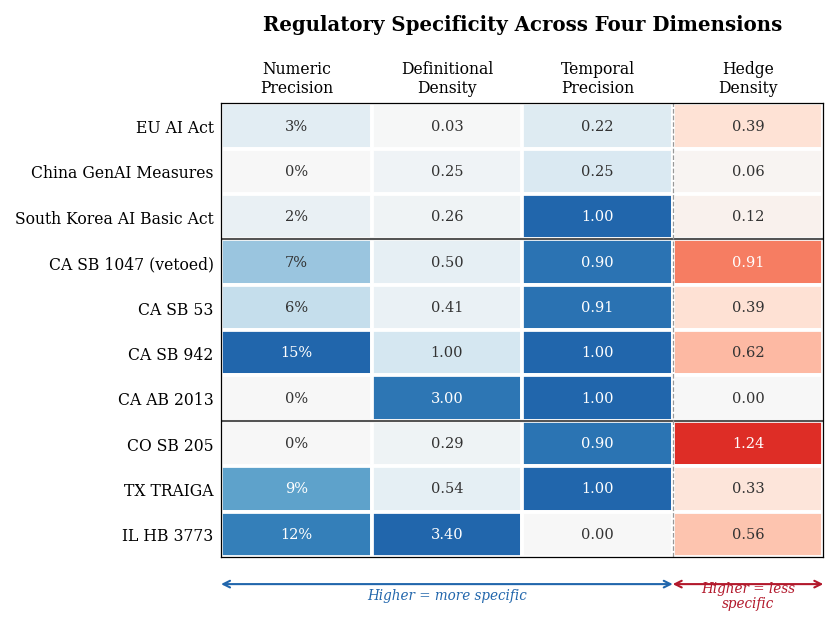

Saved: /content/drive/MyDrive/ACL SRW TEXTS/figures/fig5a_specificity_heatmap.pdf


In [ ]:
# ── Cell 7: Figure 5a — Specificity Heatmap ──

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "mathtext.fontset": "stix",
})

fig_a, ax_a = plt.subplots(figsize=(5.5, 4.2), dpi=150)

# Display raw values (not normalized) for interpretability
display_cols = ["Numeric Precision", "Definitional Density",
                "Temporal Precision", "Hedge Density"]
display_labels = ["Numeric\nPrecision", "Definitional\nDensity",
                  "Temporal\nPrecision", "Hedge\nDensity"]
data = specificity_df[display_cols].values
ylabels = [LAW_LABELS[lid] for lid in LAW_ORDER]

# Normalize each column independently for color mapping
data_normed = data.copy()
for j in range(data.shape[1]):
    col_max = data[:, j].max()
    if col_max > 0:
        data_normed[:, j] = data[:, j] / col_max

# Separate colormaps: blue for specificity, red for hedging
cmap_pos = LinearSegmentedColormap.from_list(
    "pos", ["#f7f7f7", "#d1e5f0", "#4393c3", "#2166ac"], N=256)
cmap_neg = LinearSegmentedColormap.from_list(
    "neg", ["#f7f7f7", "#fee0d2", "#fc9272", "#de2d26"], N=256)

# Draw cell by cell for dual colormaps
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        cmap = cmap_neg if j == 3 else cmap_pos
        color = cmap(data_normed[i, j])
        ax_a.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                                      facecolor=color, edgecolor="white",
                                      linewidth=1.8))
        # Annotation
        val = data[i, j]
        text_color = "white" if data_normed[i, j] > 0.55 else "#333333"
        if j == 0:
            fmt = f"{val:.0%}"
        else:
            fmt = f"{val:.2f}"
        ax_a.text(j, i, fmt, ha="center", va="center",
                 fontsize=7, color=text_color, fontweight="medium")

ax_a.set_xlim(-0.5, len(display_labels) - 0.5)
ax_a.set_ylim(len(LAW_ORDER) - 0.5, -0.5)
ax_a.set_xticks(range(len(display_labels)))
ax_a.set_xticklabels(display_labels, ha="center", fontsize=7.5,
                      linespacing=1.1)
ax_a.set_yticks(range(len(ylabels)))
ax_a.set_yticklabels(ylabels, fontsize=7.5)
ax_a.tick_params(length=0)

# Move column labels to the top
ax_a.xaxis.set_ticks_position("top")
ax_a.xaxis.set_label_position("top")

# Jurisdiction dividers
for y_line in [2.5, 6.5]:
    ax_a.axhline(y=y_line, color="#555555", linewidth=1.0)

# ── Directionality annotations BELOW the heatmap ──
# Blue arrow for first 3 columns
ax_a.annotate(
    "", xy=(2.5, len(LAW_ORDER) - 0.5 + 0.6),
    xytext=(-0.5, len(LAW_ORDER) - 0.5 + 0.6),
    arrowprops=dict(arrowstyle="<->", color="#2166ac",
                    linewidth=1.0, shrinkA=0, shrinkB=0),
    annotation_clip=False,
)
ax_a.text(1.0, len(LAW_ORDER) - 0.5 + 0.85,
          "Higher = more specific",
          ha="center", va="center", fontsize=6.5,
          color="#2166ac", fontstyle="italic",
          clip_on=False)

# Red arrow for hedge column
ax_a.annotate(
    "", xy=(3.5, len(LAW_ORDER) - 0.5 + 0.6),
    xytext=(2.5, len(LAW_ORDER) - 0.5 + 0.6),
    arrowprops=dict(arrowstyle="<->", color="#b2182b",
                    linewidth=1.0, shrinkA=0, shrinkB=0),
    annotation_clip=False,
)
ax_a.text(3.0, len(LAW_ORDER) - 0.5 + 0.85,
          "Higher = less\nspecific",
          ha="center", va="center", fontsize=6.5,
          color="#b2182b", fontstyle="italic",
          linespacing=1.1, clip_on=False)

# Thin vertical separator between blue and red zones
ax_a.axvline(x=2.5, color="#999999", linewidth=0.6, linestyle="--",
             ymin=0, ymax=1)

ax_a.set_title("Regulatory Specificity Across Four Dimensions",
               pad=35, fontweight="bold", fontsize=9.5)

fig_a.subplots_adjust(left=0.22, right=0.95, top=0.82, bottom=0.10)
fig_a.savefig(FIGURE_DIR / "fig5a_specificity_heatmap.pdf", dpi=1200,
              bbox_inches="tight", pad_inches=0.08)
plt.show()
print(f"Saved: {FIGURE_DIR / 'fig5a_specificity_heatmap.pdf'}")

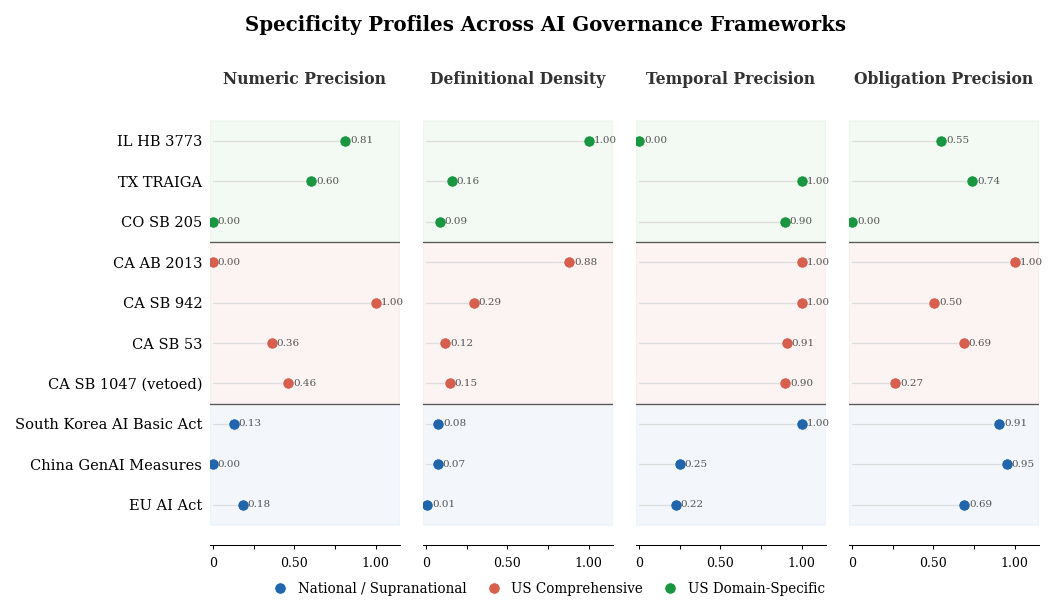

Saved: /content/drive/MyDrive/ACL SRW TEXTS/figures/fig5b_specificity_dotplot.pdf


In [ ]:
# ── Cell 8: Figure 5b — Cleveland Grouped Dot Plot ──

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 8,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "mathtext.fontset": "stix",
})

radar_cols = ["Numeric Precision", "Definitional Density",
              "Temporal Precision", "Obligation Precision"]
panel_titles = ["Numeric Precision", "Definitional Density",
                "Temporal Precision", "Obligation Precision"]

ylabels = [LAW_LABELS[lid] for lid in LAW_ORDER]
y_pos = np.arange(len(LAW_ORDER))

# Tier color per law
tier_colors = {
    "eu_ai_act": "#2166ac", "china_genai": "#2166ac", "south_korea": "#2166ac",
    "ca_sb1047": "#d6604d", "ca_sb53": "#d6604d", "ca_sb942": "#d6604d",
    "ca_ab2013": "#d6604d",
    "co_sb205": "#1a9641", "tx_traiga": "#1a9641", "il_hb3773": "#1a9641",
}
dot_colors = [tier_colors[lid] for lid in LAW_ORDER]

# Tier background shading boundaries
tier_boundaries = [(-0.5, 2.5), (2.5, 6.5), (6.5, 9.5)]
tier_shades = ["#e8f0fa", "#fae8e8", "#e8f5e8"]

fig_b, axes = plt.subplots(1, 4, figsize=(7.0, 3.8), dpi=150,
                            sharey=True)

for j, (ax, col, title) in enumerate(zip(axes, radar_cols, panel_titles)):
    values = radar_df.loc[LAW_ORDER, col].values

    # Tier background bands
    for (y0, y1), shade in zip(tier_boundaries, tier_shades):
        ax.axhspan(y0, y1, color=shade, alpha=0.5, zorder=0)

    # Jurisdiction divider lines
    for y_line in [2.5, 6.5]:
        ax.axhline(y=y_line, color="#555555", linewidth=0.6,
                   linestyle="-", zorder=1)

    # Horizontal reference lines from axis to dot (lollipop stems)
    for i, v in enumerate(values):
        ax.plot([0, v], [y_pos[i], y_pos[i]],
                color="#dddddd", linewidth=0.6, zorder=1)

    # Dots
    for i, (v, c) in enumerate(zip(values, dot_colors)):
        ax.scatter(v, y_pos[i], s=30, color=c, edgecolors="white",
                   linewidths=0.4, zorder=3)

    # Value annotations to the right of each dot
    for i, v in enumerate(values):
        ax.text(v + 0.03, y_pos[i], f"{v:.2f}",
                fontsize=5, color="#555555", ha="left", va="center")

    ax.set_xlim(-0.02, 1.15)
    ax.invert_yaxis()

    # Panel title at top
    ax.set_title(title, fontsize=7.5, fontweight="bold",
                 pad=8, color="#333333")

    # X-axis
    ax.set_xticks([0, 0.25, 0.50, 0.75, 1.00])
    ax.set_xticklabels(["0", "", "0.50", "", "1.00"], fontsize=6)
    ax.tick_params(axis="x", length=2, width=0.5)
    ax.tick_params(axis="y", length=0)

    # Spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.spines["bottom"].set_linewidth(0.5)

    # Y labels only on leftmost panel
    if j == 0:
        ax.set_yticks(y_pos)
        ax.set_yticklabels(ylabels, fontsize=7)

# ── Tier legend at bottom ──
from matplotlib.lines import Line2D
tier_handles = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#2166ac",
           markersize=5.5, markeredgecolor="white", markeredgewidth=0.4,
           label="National / Supranational"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#d6604d",
           markersize=5.5, markeredgecolor="white", markeredgewidth=0.4,
           label="US Comprehensive"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#1a9641",
           markersize=5.5, markeredgecolor="white", markeredgewidth=0.4,
           label="US Domain-Specific"),
]
fig_b.legend(handles=tier_handles, loc="lower center",
             bbox_to_anchor=(0.5, -0.03), ncol=3,
             fontsize=6.5, frameon=False,
             handletextpad=0.3, columnspacing=1.0)

fig_b.suptitle("Specificity Profiles Across AI Governance Frameworks",
               fontweight="bold", fontsize=9.5, y=1.01)

fig_b.subplots_adjust(left=0.18, right=0.97, top=0.86, bottom=0.08,
                       wspace=0.12)
fig_b.savefig(FIGURE_DIR / "fig5b_specificity_dotplot.pdf", dpi=1200,
              bbox_inches="tight", pad_inches=0.08)
plt.show()
print(f"Saved: {FIGURE_DIR / 'fig5b_specificity_dotplot.pdf'}")

In [ ]:
# ── Cell 9: Key statistics for paper text ──

print("\n" + "=" * 70)
print("KEY STATISTICS FOR PAPER TEXT")
print("=" * 70)

for law_id in LAW_ORDER:
    nr = numeric_results[law_id]
    dr = definitional_results[law_id]
    tr = temporal_results[law_id]
    hr = hedge_results[law_id]

    print(f"\n{LAW_LABELS[law_id]}:")
    print(f"  Numeric precision: {nr['ratio']:.1%} of obligation sentences "
          f"contain numeric values ({nr['sents_with_numeric']}/{nr['n_obligation']})")
    print(f"  Definitional density: {dr['density']:.3f} "
          f"({dr['defined_terms']} defined terms / {dr['recurring_nps']} recurring NPs)")
    print(f"  Temporal precision: {tr['ratio']:.2f} "
          f"({tr['precise']} precise / {tr['vague']} vague)")
    print(f"  Hedge density: {hr['density']:.3f} "
          f"({hr['total_hedges']} hedges / {hr['n_obligation']} obligation sents)")


KEY STATISTICS FOR PAPER TEXT

EU AI Act:
  Numeric precision: 2.8% of obligation sentences contain numeric values (20/710)
  Definitional density: 0.031 (13 defined terms / 420 recurring NPs)
  Temporal precision: 0.22 (11 precise / 38 vague)
  Hedge density: 0.386 (274 hedges / 710 obligation sents)

China GenAI Measures:
  Numeric precision: 0.0% of obligation sentences contain numeric values (0/16)
  Definitional density: 0.250 (1 defined terms / 4 recurring NPs)
  Temporal precision: 0.25 (1 precise / 3 vague)
  Hedge density: 0.062 (1 hedges / 16 obligation sents)

South Korea AI Basic Act:
  Numeric precision: 2.0% of obligation sentences contain numeric values (2/102)
  Definitional density: 0.256 (10 defined terms / 39 recurring NPs)
  Temporal precision: 1.00 (2 precise / 0 vague)
  Hedge density: 0.118 (12 hedges / 102 obligation sents)

CA SB 1047 (vetoed):
  Numeric precision: 7.1% of obligation sentences contain numeric values (4/56)
  Definitional density: 0.500 (19 def

In [ ]:
# ── Cell 10: Export ──

export = {}
for law_id in LAW_ORDER:
    export[law_id] = {
        "numeric_precision": {
            "ratio": numeric_results[law_id]["ratio"],
            "sents_with_numeric": numeric_results[law_id]["sents_with_numeric"],
            "n_obligation": numeric_results[law_id]["n_obligation"],
        },
        "definitional_density": {
            "density": definitional_results[law_id]["density"],
            "defined_terms": definitional_results[law_id]["defined_terms"],
            "recurring_nps": definitional_results[law_id]["recurring_nps"],
        },
        "temporal_precision": {
            "ratio": temporal_results[law_id]["ratio"],
            "precise": temporal_results[law_id]["precise"],
            "vague": temporal_results[law_id]["vague"],
        },
        "hedge_density": {
            "density": hedge_results[law_id]["density"],
            "total_hedges": hedge_results[law_id]["total_hedges"],
            "n_obligation": hedge_results[law_id]["n_obligation"],
        },
    }

export_path = OUTPUT_DIR / "technique4_specificity.json"
with open(export_path, "w", encoding="utf-8") as f:
    json.dump(export, f, indent=2)
print(f"\nResults saved to: {export_path}")


Results saved to: /content/drive/MyDrive/ACL SRW TEXTS/processed/technique4_specificity.json
